In [11]:
# MBA notebook -- setup & load clustering handoff
import pickle, warnings, re, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

with open('clustering_handoff.pkl', 'rb') as _f:
    _h = pickle.load(_f)

df_units          = _h['df_units']
df_used_market    = _h['df_used_market']
name_map          = _h['name_map']
segmentation_data = _h['segmentation_data']
scaled_features   = _h['scaled_features']
scaler            = _h['scaler']
FEATURES          = _h['FEATURES']
df_core           = _h['df_core']
df_whale          = _h['df_whale']
gmm_core          = _h['gmm_core']
best_k_core       = _h['best_k_core']
lrfm              = _h.get('lrfm', None)

print('Clustering handoff loaded.')
print(f'  df_units          {df_units.shape}')
print(f'  df_used_market    {df_used_market.shape}')
print(f'  segmentation_data {segmentation_data.shape}')
print(f'  df_core           {df_core.shape}   ({best_k_core} Stage2 clusters)')
print(f'  df_whale          {df_whale.shape}')
print(f'  lrfm loaded       {lrfm is not None}')
print(f'  name_map keys     {len(name_map)}')

# Stage2 cluster mapping: RUC -> cluster label (core importers only)
stage2_map = df_core['Stage2_Cluster'].to_dict()
print(f'\nStage 2 cluster sizes:')
print(df_core['Stage2_Cluster'].value_counts().sort_index())


Clustering handoff loaded.
  df_units          (7539, 39)
  df_used_market    (10239, 38)
  segmentation_data (1444, 9)
  df_core           (1371, 11)   (7 Stage2 clusters)
  df_whale          (73, 9)
  lrfm loaded       True
  name_map keys     4234

Stage 2 cluster sizes:
Stage2_Cluster
0    126
1    870
2      2
3    201
4     41
5      7
6    124
Name: count, dtype: int64


In [13]:
# ── Enrich UNKNOWN MARCA / MODELO from DESCRIPTION_MERGED ────────────────────
# Uses make-model-cptrucks.xlsx as a reference dictionary.
# Two-pass approach:
#   1. Dictionary lookup  — exact model names from the Excel
#   2. Regex extraction   — model codes embedded in serial numbers / free text
import re
import pandas as pd

ref = pd.read_excel('make-model-cptrucks.xlsx')

# Non-makes and non-informative model strings to skip
_JUNK_MAKES  = {'BUCKET', 'CONTAINER', 'SPARE', 'SKID'}
_JUNK_MODELS = {'HAMMER', 'SPARE', 'PARTS', 'BLAUW', 'CONE', 'HOSE', 'III', 'NAN', 'NONE', ''}

# Build {UPPER_MAKE: {canonical, models}} from the Excel
_make_models = {}
for _, row in ref.iterrows():
    make  = str(row['make']).strip()
    model = str(row['model']).strip() if pd.notna(row['model']) else ''
    key   = make.upper()
    if key in _JUNK_MAKES:
        continue
    if key not in _make_models:
        _make_models[key] = {'canonical': make, 'models': set()}
    if model.upper() not in _JUNK_MODELS:
        _make_models[key]['models'].add(model)

# Longest make names first (prevents 'SYMONS' matching before 'SYMONS/METSO')
_sorted_makes = sorted(_make_models.keys(), key=len, reverse=True)

# Regex patterns to extract model codes from serial numbers / free text
_MODEL_REGEX = {
    'CATERPILLAR': [
        r'\bCAT0?([A-Z]{0,2}[0-9]{2,4}[A-Z]{0,2})\b',  # 962H, M322C, 262C, 329DL
        r'\b(IT[0-9]{2}[A-Z]?)\b',                       # IT14G
        r'\b(140[A-Z][0-9]?)\b',                         # 140M2, 140H
    ],
    'VOLVO': [
        r'\b([ELF][0-9]{2,3}[A-Z]{0,2})\b',             # L120C, L180, EW170, L90C
    ],
    'GOMACO': [
        r'\b(GT[0-9]{4}|[0-9]{3,4})\b',                 # GT6300, 603
    ],
}

def _extract_model_regex(make_key, desc_up):
    for pat in _MODEL_REGEX.get(make_key, []):
        m = re.search(pat, desc_up)
        if m:
            return m.group(1)
    return None

def _enrich_row(marca, modelo, desc):
    """Return (enriched_marca, enriched_modelo). Only fills UNKNOWN slots."""
    marca_unk = str(marca).upper().strip() in ('UNKNOWN', '', 'NAN')
    model_unk = str(modelo).upper().strip() in ('UNKNOWN', '', 'NAN')
    if not marca_unk and not model_unk:
        return marca, modelo

    desc_up = str(desc).upper() if pd.notna(desc) else ''

    # Find make in description
    found_key = None
    for key in _sorted_makes:
        if re.search(r'\b' + re.escape(key) + r'\b', desc_up):
            found_key = key
            break
    # CAT appears inside serial numbers without a strict word boundary
    if found_key is None and re.search(r'\bCAT\b', desc_up):
        found_key = 'CATERPILLAR'

    if found_key is None:
        return marca, modelo

    new_marca  = _make_models[found_key]['canonical'] if marca_unk else marca
    new_modelo = modelo

    if model_unk:
        # Pass 1: exact dictionary match
        for model in _make_models[found_key]['models']:
            if re.search(r'\b' + re.escape(model.upper()) + r'\b', desc_up):
                new_modelo = model
                break
        # Pass 2: regex extraction from serial / free text
        if str(new_modelo).upper().strip() in ('UNKNOWN', '', 'NAN'):
            extracted = _extract_model_regex(found_key, desc_up)
            if extracted:
                new_modelo = extracted

    return new_marca, new_modelo

# Apply to df_units in-place
_unk_before_marca  = (df_units['MARCA'].str.upper().str.strip() == 'UNKNOWN').sum()
_unk_before_modelo = (df_units['MODELO'].str.upper().str.strip() == 'UNKNOWN').sum()

_enriched = df_units.apply(
    lambda r: pd.Series(
        _enrich_row(r['MARCA'], r['MODELO'], r.get('DESCRIPTION_MERGED', '')),
        index=['MARCA', 'MODELO']
    ), axis=1
)
df_units['MARCA']  = _enriched['MARCA']
df_units['MODELO'] = _enriched['MODELO']

_unk_after_marca  = (df_units['MARCA'].str.upper().str.strip() == 'UNKNOWN').sum()
_unk_after_modelo = (df_units['MODELO'].str.upper().str.strip() == 'UNKNOWN').sum()

print("── MARCA/MODELO enrichment from make-model-cptrucks.xlsx ───────────────")
print(f"  MARCA  UNKNOWN: {_unk_before_marca:>4} → {_unk_after_marca:>4}"
      f"  ({_unk_before_marca - _unk_after_marca} resolved,"
      f" {(_unk_before_marca - _unk_after_marca)/_unk_before_marca*100:.1f}%)")
print(f"  MODELO UNKNOWN: {_unk_before_modelo:>4} → {_unk_after_modelo:>4}"
      f"  ({_unk_before_modelo - _unk_after_modelo} resolved,"
      f" {(_unk_before_modelo - _unk_after_modelo)/_unk_before_modelo*100:.1f}%)")


── MARCA/MODELO enrichment from make-model-cptrucks.xlsx ───────────────
  MARCA  UNKNOWN:  215 →  195  (20 resolved, 9.3%)
  MODELO UNKNOWN:  429 →  414  (15 resolved, 3.5%)


In [552]:
# ── Standardise MARCA: fix typos, prefix noise, and variant names ────────────
# Two-pass approach:
#   1. Hard-coded canonical map  — prefix noise (M/VOLVO, MARCA:CAT) and known typos
#   2. Fuzzy matching (rapidfuzz) — remaining typos caught automatically at ≥82% similarity
from rapidfuzz import process, fuzz

# ── Pass 1: canonical correction map ─────────────────────────────────────────
_CANON = {
    # Caterpillar — prefix noise + typos
    'CAT': 'CATERPILLAR', 'CAT CATERPILLAR': 'CATERPILLAR',
    'CAT / CATERPILLAR': 'CATERPILLAR', 'CAT(CATERPILLAR)': 'CATERPILLAR',
    'CATERPILLAR (CAT)': 'CATERPILLAR', 'CATERPILLAR INC': 'CATERPILLAR',
    'CATERPILLAR(CAT)': 'CATERPILLAR',
    'M/CATERPILLAR': 'CATERPILLAR', 'M/.CATERPILLAR': 'CATERPILLAR',
    'M: CATERPILLAR': 'CATERPILLAR', 'M:/CATERPILLAR': 'CATERPILLAR',
    'M:CATERPILLAR': 'CATERPILLAR', 'MARCA: CATERPILLAR': 'CATERPILLAR',
    'MARCA:CATERPILLAR': 'CATERPILLAR',
    # Volvo
    'VOL': 'VOLVO', 'VOLVO BM': 'VOLVO', 'VOLVO PM AB': 'VOLVO',
    'M/VOLVO': 'VOLVO', 'M/VOLVO BM': 'VOLVO', 'M:VOLVO': 'VOLVO',
    'MARCA :VOLVO': 'VOLVO', 'MARCA: VOLVO': 'VOLVO', 'MARCA:VOLVO': 'VOLVO',
    # Komatsu
    'M:KOMATSU': 'KOMATSU', 'MOKATSU': 'KOMATSU',
    # John Deere
    'JHON DEERE': 'JOHN DEERE', 'JOHN DEERE 320D': 'JOHN DEERE', 'DEERE': 'JOHN DEERE',
    # Bobcat
    'BOB CAT': 'BOBCAT', 'BOTBCAT': 'BOBCAT',
    # Ingersoll Rand
    'INGERSOL RAND': 'INGERSOLL RAND', 'INGERSOLL-RAND': 'INGERSOLL RAND',
    'INGRESOLL-RAND': 'INGERSOLL RAND',
    # Doosan / Daewoo
    'DOSSAN': 'DOOSAN', 'DAEWOO DOOSAN': 'DOOSAN', 'DAEWOO-DOOSAN': 'DOOSAN',
    'DAEWO': 'DAEWOO',
    # Morgardshammar
    'MORGARD SHAMMAR': 'MORGARDSHAMMAR', 'MORGARDHAMMAR': 'MORGARDSHAMMAR',
    'MORGARDSHA MMAR': 'MORGARDSHAMMAR', 'MORGARSHAMAR': 'MORGARDSHAMMAR',
    'MOGARDSHAMMAR': 'MORGARDSHAMMAR',
    # Sandvik
    'SANDIVIK': 'SANDVIK', 'SANDVIC': 'SANDVIK', 'TAMROCK-SANVIK': 'SANDVIK',
    # Atlas Copco
    'ATLAS COPCO.': 'ATLAS COPCO', 'M/ATLAS COPCO': 'ATLAS COPCO',
    # Liugong
    'LIUNGONG': 'LIUGONG', 'LIUGONG 856H': 'LIUGONG', 'LIUGONG LOADER': 'LIUGONG',
    'LINGONG': 'LIUGONG',
    # Powerscreen
    'POWER SCREEN': 'POWERSCREEN', 'POWER SCREEN MACHINE': 'POWERSCREEN',
    'POWERSCREEM': 'POWERSCREEN',
    # McCloskey
    'MC CLOSKEY': 'MCCLOSKEY', 'MCKCLOSKEY': 'MCCLOSKEY',
    'MCCLOSKEY INTERNATIONAL': 'MCCLOSKEY',
    # Hyundai
    'HIUNDAY': 'HYUNDAI', 'HYUNDAI ROBEX': 'HYUNDAI',
    # Vogele
    'VOEGELE': 'VOGELE',
    # Svedala
    'SVEDLA': 'SVEDALA', 'SVEDAIA NO OPERATIVA': 'SVEDALA',
    # Allis Chalmers
    'ALLIS CHALMER': 'ALLIS CHALMERS', 'ALLIS CHAMLMBERS': 'ALLIS CHALMERS',
    # Kue Ken
    'KUE-KEN': 'KUE KEN', 'KUEKEN': 'KUE KEN',
    # Changlin / Taizhong
    'CHANG LIN': 'CHANGLIN', 'TAI ZHONG': 'TAIZHONG',
    # Fiat variants
    'FIAT-HITACHI': 'FIAT HITACHI', 'FIATALLIS': 'FIAT ALLIS',
    # Terex
    'TEREX-FINLAY': 'TEREX FINLAY', 'M:TEREX': 'TEREX',
    # Metso / Nordberg
    'METSO NORDBERG': 'METSO', 'NORDBERG-METSO': 'METSO', 'METSO/NORDBERG': 'METSO',
    'METSO LOKOMO': 'METSO',
    # Klemm
    'KLEMM BOHRTECHENICK': 'KLEMM', 'KLEMM BOHRTECHNIK': 'KLEMM',
    'CHENILLES KLEMM': 'KLEMM',
    # Kleemann
    'KLEEMAN': 'KLEEMANN',
    # Soilmec
    'M/SOILMEC': 'SOILMEC',
    # No-brand tokens → UNKNOWN
    'S/M': 'UNKNOWN', 'SIN MARCA': 'UNKNOWN', 'S/MARCA': 'UNKNOWN',
    '::::::': 'UNKNOWN', '950H': 'UNKNOWN', 'CAT0320DEPBE02568': 'UNKNOWN',
    'LOADER MACHINE': 'UNKNOWN', 'SHRERPILLAR': 'UNKNOWN',
}

def _apply_canon(val):
    v = str(val).strip().upper()
    return _CANON.get(v, val.strip())

# ── Pass 2: fuzzy matching for remaining typos ────────────────────────────────
_CANONICAL_BRANDS = [
    'CATERPILLAR','VOLVO','KOMATSU','DOOSAN','DAEWOO','HYUNDAI','JOHN DEERE',
    'BOBCAT','CASE','HITACHI','LIEBHERR','SANDVIK','JCB','ATLAS COPCO','SANY',
    'XCMG','LIUGONG','SDLG','INGERSOLL RAND','DYNAPAC','HAMM','BOMAG','WIRTGEN',
    'ROADTEC','VOGELE','AMMANN','NEW HOLLAND','SAMSUNG','YANMAR','KUBOTA',
    'KOBELCO','TEREX','POWERSCREEN','MCCLOSKEY','METSO','SYMONS','NORDBERG',
    'MORGARDSHAMMAR','SVEDALA','BERGEAUD','CFBK','KRUPP','HAZEMAG','PEGSON',
    'CEDARAPIDS','TELSMITH','GOMACO','VERMEER','DITCH WITCH','MANITOU','MERLO',
    'GEHL','FIAT ALLIS','FIAT HITACHI','FIAT KOBELCO','WACKER NEUSON','EPIROC',
    'KLEMM','KLEEMANN','SOILMEC','ALLIS CHALMERS','CHAMPION','LEEBOY',
    'BERGKAMP','FINLAY','RESEMIN','NORMET','PUTZMEISTER','COMACCHIO',
    'CHANGLIN','TAIZHONG','KUE KEN',
]
_known_upper = {b.upper() for b in _CANONICAL_BRANDS} | {'UNKNOWN'}
_brands_upper = [b.upper() for b in _CANONICAL_BRANDS]

# Build fuzzy map on first run (operates on unique values only — fast)
_before_canon = df_units['MARCA'].str.strip().map(_apply_canon)
_needs_fuzzy  = _before_canon[~_before_canon.str.upper().isin(_known_upper)].unique()

_fuzzy_map = {}
for val in _needs_fuzzy:
    hit = process.extractOne(val.upper(), _brands_upper,
                             scorer=fuzz.token_sort_ratio, score_cutoff=82)
    if hit:
        _fuzzy_map[val] = next(b for b in _CANONICAL_BRANDS if b.upper() == hit[0])

# ── Apply both passes ─────────────────────────────────────────────────────────
_n_before = df_units['MARCA'].str.upper().str.strip().nunique()

df_units['MARCA'] = (
    df_units['MARCA']
    .str.strip()
    .map(_apply_canon)
    .replace(_fuzzy_map)
)

_n_after = df_units['MARCA'].str.upper().str.strip().nunique()

print(f"MARCA unique values: {_n_before} → {_n_after}  ({_n_before - _n_after} variants collapsed)")
print(f"Fuzzy corrections applied: {len(_fuzzy_map)}")
print(f"\nTop 15 brands after standardisation:")
print(df_units['MARCA'].value_counts().head(15).to_string())

MARCA unique values: 249 → 247  (2 variants collapsed)
Fuzzy corrections applied: 0

Top 15 brands after standardisation:
MARCA
CATERPILLAR    3141
VOLVO          2590
HYUNDAI         219
UNKNOWN         197
DOOSAN          164
KOMATSU         105
BOBCAT           64
JOHN DEERE       59
SYMONS           59
Caterpillar      45
LIUGONG          40
HITACHI          39
ATLAS COPCO      33
SANDVIK          32
CASE             30


In [15]:
# 1. Create the Audit Table
# We group by Brand and Model and count how many times they appear
brand_model_audit = (
    df_units.groupby(['MARCA', 'MODELO', 'PRODUCTO'])
    .size()
    .reset_index(name='Frecuencia')
    .sort_values(by='Frecuencia', ascending=False)
)

# 2. Show the top of the list to identify "High-Volume" parts/models
print("--- Top 20 Brand + Model Combinations ---")
print(brand_model_audit.head(20))

# 3. Export to CSV for manual review (Excel is better for "scanning" thousands of rows)
#brand_model_audit.to_csv("BRAND_MODEL_AUDIT.csv", index=False)
#brand_model_audit.to_pickle("BRAND_MODEL_AUDIT.pkl")

print("\nFiles exported: 'BRAND_MODEL_AUDIT.csv' and 'BRAND_MODEL_AUDIT.pkl'")

--- Top 20 Brand + Model Combinations ---
            MARCA     MODELO          PRODUCTO  Frecuencia
2451        VOLVO      L150F  CARGADOR FRONTAL         182
462   CATERPILLAR      325BL        EXCAVADORA         181
2468        VOLVO      L150H  CARGADOR FRONTAL         175
2442        VOLVO      L150E  CARGADOR FRONTAL         167
2161      UNKNOWN    UNKNOWN           UNKNOWN         145
2386        VOLVO      L120C  CARGADOR FRONTAL         131
2458        VOLVO      L150G  CARGADOR FRONTAL         119
558   CATERPILLAR      329EL        EXCAVADORA         115
2268        VOLVO    EC350EL        EXCAVADORA          94
2402        VOLVO      L120E  CARGADOR FRONTAL          81
2412        VOLVO      L120F  CARGADOR FRONTAL          79
2296        VOLVO    EC380EL        EXCAVADORA          74
605   CATERPILLAR      330FL        EXCAVADORA          70
185   CATERPILLAR       140K    MOTONIVELADORA          69
2482        VOLVO      L180F  CARGADOR FRONTAL          64
2379        VO

In [17]:
# Use the already-loaded df_used_market from the handoff
df_used = df_used_market.copy()

# Rescue UNKNOWN MODELOs from description text
def rescue_model(row):
    if str(row.get('MODELO', '')).upper() in ('UNKNOWN', '::::::'):
        desc = str(row.get('DESCRIPCION DE MERCANCIA 1', '')).upper()
        match = re.search(r'\b([A-Z]*\d{3}[A-Z]*)\b', desc)
        return match.group(0) if match else 'UNKNOWN'
    return row.get('MODELO', 'UNKNOWN')

df_used['MODELO_CLEAN'] = df_used.apply(rescue_model, axis=1)

# Build df_iron: used-market whole machines only (IS_MACHINE flag set in preprocessing)
df_iron = df_used[
    df_used.get('IS_MACHINE', pd.Series(True, index=df_used.index))
    if 'IS_MACHINE' in df_used.columns
    else pd.Series(True, index=df_used.index)
].copy()

# Standardise MARCA_CLEAN and PRODUCTO_CLEAN for basket columns
df_iron['MARCA']    = df_iron.get('MARCA_CLEAN',    df_iron.get('MARCA',    'UNKNOWN')).fillna('UNKNOWN')
df_iron['PRODUCTO'] = df_iron.get('PRODUCTO_CLEAN', df_iron.get('PRODUCTO', 'UNKNOWN')).fillna('UNKNOWN')
df_iron['BRAND_TYPE'] = df_iron['MARCA'] + '_' + df_iron['PRODUCTO']

print(f'df_iron shape: {df_iron.shape}')
print(f'Unique BRAND_TYPEs: {df_iron["BRAND_TYPE"].nunique()}')


df_iron shape: (8475, 40)
Unique BRAND_TYPEs: 498


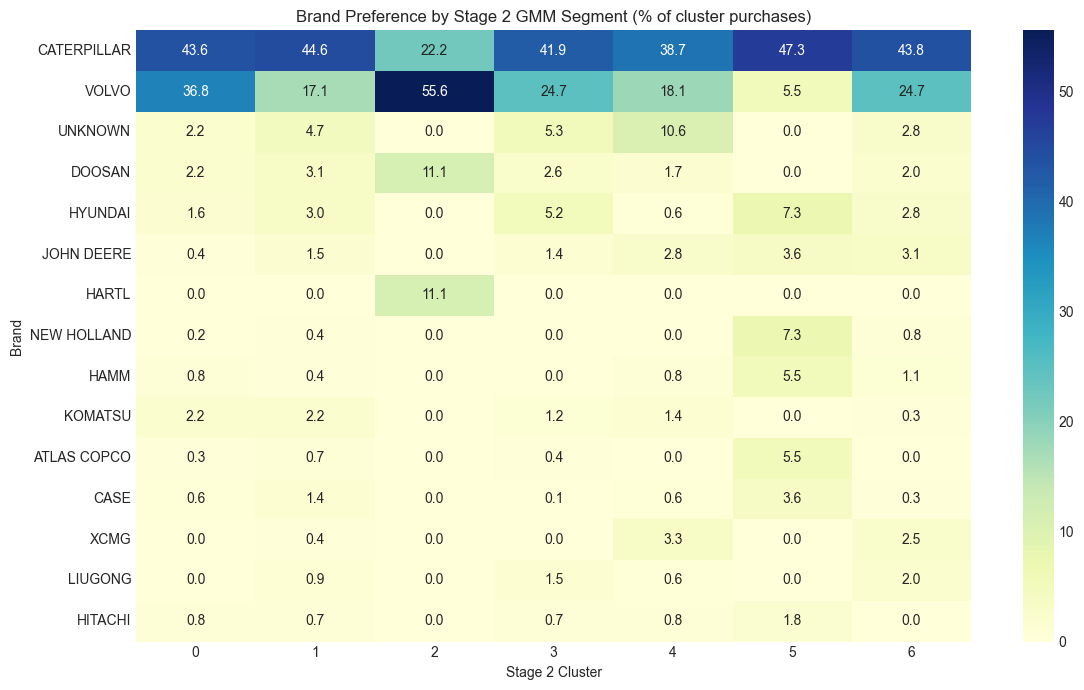

In [19]:
# Map Stage 2 GMM cluster to df_iron
# stage2_map: RUC -> Stage2_Cluster (core importers only; whales get NaN)
df_iron['Stage2_Cluster'] = df_iron['RUC IMPORTADOR'].astype(str).map(
    {str(k): v for k, v in stage2_map.items()}
)

# Brand affinity heatmap: which brands does each Stage 2 segment prefer?
_iron_core = df_iron[df_iron['Stage2_Cluster'].notna()].copy()
_iron_core['Stage2_Cluster'] = _iron_core['Stage2_Cluster'].astype(int)

brand_affinity = pd.crosstab(
    _iron_core['MARCA'],
    _iron_core['Stage2_Cluster'],
    normalize='columns'
) * 100

top_brands = brand_affinity.sum(axis=1).nlargest(15).index
plt.figure(figsize=(12, 7))
sns.heatmap(brand_affinity.loc[top_brands], annot=True, fmt='.1f', cmap='YlGnBu')
plt.title('Brand Preference by Stage 2 GMM Segment (% of cluster purchases)')
plt.xlabel('Stage 2 Cluster'); plt.ylabel('Brand')
plt.tight_layout(); plt.show()


In [25]:
from mlxtend.frequent_patterns import fpgrowth, association_rules

# 1. Group by your composite field BRAND_TYPE instead of raw MARCA
# 2. Use a direct boolean comparison (> 0) to eliminate the DeprecationWarning
basket_sets = (df_iron.groupby(['RUC IMPORTADOR', 'MARCA'])['US$ FOB']
               .count()
               .unstack()
               .fillna(0) > 0)

# 3. Filter your basket matrix columns to the top 30 items as written in your chapter
top_30_items = df_iron['MARCA'].value_counts().head(30).index
basket_sets = basket_sets[basket_sets.columns.intersection(top_30_items)]

# 4. Run FP-Growth as stated in your parsimonious methodology section
frequent_itemsets = fpgrowth(basket_sets, min_support=0.03, use_colnames=True)

# 5. Generate association rules using the correct lift threshold
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.2)

# 6. Display your final results to fill in your Table 4.1 values
columns_to_show = ['antecedents', 'consequents', 'support', 'confidence', 'lift']
final_rules = rules[columns_to_show].sort_values(by='lift', ascending=False)

print(final_rules)

Empty DataFrame
Columns: [antecedents, consequents, support, confidence, lift]
Index: []


In [29]:
from mlxtend.frequent_patterns import fpgrowth, association_rules

# 1. Create the composite column
df_iron['BRAND_TYPE'] = df_iron['MARCA'] + "_" + df_iron['PRODUCTO']

# 2. Pivot into a basket matrix
basket_model = (df_iron.groupby(['RUC IMPORTADOR', 'BRAND_TYPE'])['US$ FOB']
                .count().unstack().fillna(0))

# 3. Filter to the top 30 items by transaction frequency as written in your text
top_30_items = df_iron['BRAND_TYPE'].value_counts().head(30).index
basket_model = basket_model[basket_model.columns.intersection(top_30_items)]

# 4. Convert to boolean directly using a comparison to eradicate the warning
basket_model_sets = basket_model > 0

# 5. Run FP-Growth instead of Apriori to match your methodology text
# Note: Use min_support=0.03 to match your global baseline section exactly
frequent_itemsets_model = fpgrowth(basket_model_sets, min_support=0.03, use_colnames=True)

# 6. Generate association rules using your text baseline thresholds (min_lift=1.2)
rules_model = association_rules(frequent_itemsets_model, metric="lift", min_threshold=1.2)

# 7. Print your final rules sorted by lift
print("\n--- Market Basket Analysis Final Rules ---")
print(rules_model[['antecedents', 'consequents', 'support', 'confidence', 'lift']].sort_values('lift', ascending=False))


--- Market Basket Analysis Final Rules ---
                           antecedents                          consequents  \
0  frozenset({VOLVO_CARGADOR FRONTAL})        frozenset({VOLVO_EXCAVADORA})   
1        frozenset({VOLVO_EXCAVADORA})  frozenset({VOLVO_CARGADOR FRONTAL})   
2  frozenset({CATERPILLAR_EXCAVADORA})        frozenset({VOLVO_EXCAVADORA})   
3        frozenset({VOLVO_EXCAVADORA})  frozenset({CATERPILLAR_EXCAVADORA})   

    support  confidence      lift  
0  0.040804    0.186782  2.171847  
1  0.040804    0.474453  2.171847  
2  0.033271    0.106212  1.235010  
3  0.033271    0.386861  1.235010  


In [33]:
from mlxtend.frequent_patterns import fpgrowth, association_rules

# 1. Create a cleaner Brand_Type column
df_iron['BRAND_TYPE'] = df_iron['MARCA'] + "_" + df_iron['PRODUCTO']

# 2. Filter for only the Top 30 most frequent combinations to reduce noise and complexity
top_combos = df_iron['BRAND_TYPE'].value_counts().nlargest(30).index
df_filtered = df_iron[df_iron['BRAND_TYPE'].isin(top_combos)]

# 3. Create the basket
basket_iron = (df_filtered.groupby(['RUC IMPORTADOR', 'BRAND_TYPE'])['US$ FOB']
               .count().unstack().fillna(0))

# Binary encoding: Convert directly to boolean data type to eliminate the performance warning
basket_iron_sets = basket_iron > 0

# 4. Use fpgrowth instead of apriori (Faster!)
# We set min_support to 0.03 (at least 3% of importers buy both)
frequent_itemsets_iron = fpgrowth(basket_iron_sets, min_support=0.03, use_colnames=True)

# 5. Generate Rules
rules_iron = association_rules(frequent_itemsets_iron, metric="lift", min_threshold=1.2)

# Sort and clean output to avoid JavaScript lag
rules_iron_clean = rules_iron[['antecedents', 'consequents', 'support', 'confidence', 'lift']].sort_values('lift', ascending=False)
print(f"Discovered {len(rules_iron_clean)} associations.")
display(rules_iron_clean.head(15))

Discovered 8 associations.


,antecedents,consequents,support,confidence,lift
2,"frozenset({CATERPILLAR_EXCAVADORA, VOLVO_CARGA...",frozenset({VOLVO_EXCAVADORA}),0.030143,0.307692,2.980348
7,frozenset({VOLVO_EXCAVADORA}),"frozenset({CATERPILLAR_EXCAVADORA, VOLVO_CARGA...",0.030143,0.291971,2.980348
3,"frozenset({CATERPILLAR_EXCAVADORA, VOLVO_EXCAV...",frozenset({VOLVO_CARGADOR FRONTAL}),0.030143,0.754717,2.877901
6,frozenset({VOLVO_CARGADOR FRONTAL}),"frozenset({CATERPILLAR_EXCAVADORA, VOLVO_EXCAV...",0.030143,0.114943,2.877901
0,frozenset({VOLVO_CARGADOR FRONTAL}),frozenset({VOLVO_EXCAVADORA}),0.048983,0.186782,1.809191
1,frozenset({VOLVO_EXCAVADORA}),frozenset({VOLVO_CARGADOR FRONTAL}),0.048983,0.474453,1.809191
5,frozenset({CATERPILLAR_EXCAVADORA}),"frozenset({VOLVO_CARGADOR FRONTAL, VOLVO_EXCAV...",0.030143,0.080160,1.636504
4,"frozenset({VOLVO_CARGADOR FRONTAL, VOLVO_EXCAV...",frozenset({CATERPILLAR_EXCAVADORA}),0.030143,0.615385,1.636504


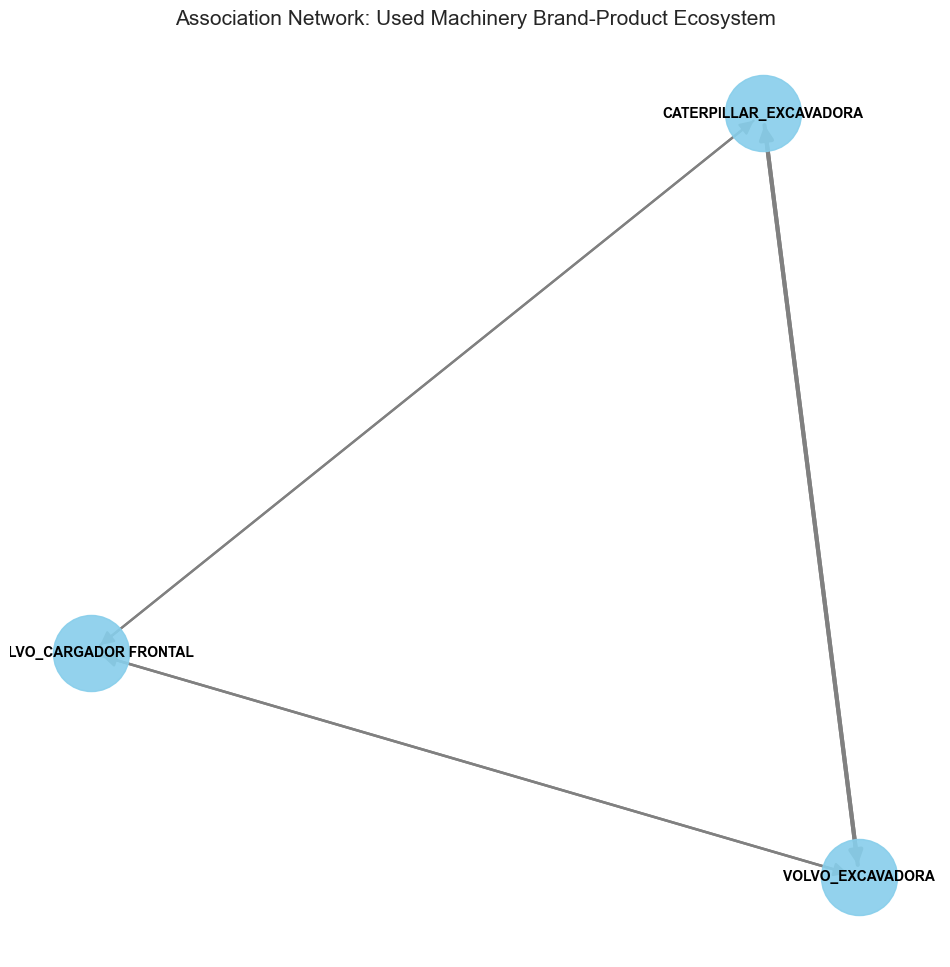

In [35]:
import networkx as nx

# Create the graph object
G = nx.DiGraph()

# Add edges based on your Top 10 rules
# We'll use 'Lift' to determine the thickness of the connection
for idx, row in rules_iron_clean.head(12).iterrows():
    ant = list(row['antecedents'])[0]
    con = list(row['consequents'])[0]
    G.add_edge(ant, con, weight=row['lift'])

# Positioning the nodes
plt.figure(figsize=(12, 12))
pos = nx.spring_layout(G, k=1.5) # k adjusts the distance between nodes

# Draw the nodes and labels
nx.draw_networkx_nodes(G, pos, node_size=3000, node_color='skyblue', alpha=0.9)
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

# Draw the edges (thickness based on Lift)
weights = [G[u][v]['weight'] for u, v in G.edges()]
nx.draw_networkx_edges(G, pos, width=weights, edge_color='gray', arrowsize=20)

plt.title('Association Network: Used Machinery Brand-Product Ecosystem', size=15)
plt.axis('off')
plt.show()

In [37]:
# Single-cluster rule check: find the target cluster (where CPtrucks clients sit)
CP_CLIENTS = ['20490425668', '20517931536', '20602250866']
_cp_clusters = df_core[
    df_core.index.astype(str).isin(CP_CLIENTS)
]['Stage2_Cluster']
_target_cl = int(_cp_clusters.mode()[0]) if not _cp_clusters.empty else 0
print(f'CPtrucks clients are in Stage 2 Cluster: {_target_cl}')

# Filter basket to importers in this cluster
target_rucs = df_core[df_core['Stage2_Cluster'] == _target_cl].index.astype(str)
basket_target = basket_sets.loc[basket_sets.index.isin(target_rucs)]
print(f'Basket rows in target cluster: {len(basket_target)}')

if len(basket_target) >= 5:
    from mlxtend.frequent_patterns import fpgrowth, association_rules
    freq_target = fpgrowth(basket_target, min_support=0.05, use_colnames=True)
    if not freq_target.empty:
        rules_target = association_rules(freq_target, metric='lift', min_threshold=1.1)
        print(f'\nRules for Stage 2 Cluster {_target_cl} (CPtrucks segment):')
        display(
            rules_target[['antecedents', 'consequents', 'confidence', 'lift']]
            .sort_values('lift', ascending=False).head(10)
        )
    else:
        print('No frequent itemsets at min_support=0.05 for this cluster.')
else:
    print('Not enough importers in this cluster for independent FP-Growth.')


CPtrucks clients are in Stage 2 Cluster: 0
Basket rows in target cluster: 126

Rules for Stage 2 Cluster 0 (CPtrucks segment):


,antecedents,consequents,confidence,lift
0,frozenset({UNKNOWN}),frozenset({CATERPILLAR}),0.900000,1.111765
1,frozenset({CATERPILLAR}),frozenset({UNKNOWN}),0.088235,1.111765


In [39]:
# 1. Clean the 'Iron' dataset one last time (Surgical Approach)
df_clean_iron = df_iron[df_iron['BRAND_TYPE'].str.contains('UNKNOWN') == False].copy()

# 2. Sort by RUC and Year to create the timeline
df_timeline = df_clean_iron.sort_values(['RUC IMPORTADOR', 'ANO'])

# 3. Create the 'Sequence'
# We find the FIRST thing they ever bought vs the REST of their history
sequences = df_timeline.groupby('RUC IMPORTADOR')['BRAND_TYPE'].agg(list)

# Function to identify the 'Gateway' (First) and 'Expansion' (Subsequent) machines
def analyze_growth(seq):
    if len(seq) < 2: return None
    first = seq[0]
    subsequent = list(set(seq[1:])) # Unique machines bought after the first year
    return (first, subsequent)

growth_patterns = sequences.apply(analyze_growth).dropna()

# 4. Count the 'Gateway' Machines
gateways = pd.Series([x[0] for x in growth_patterns]).value_counts()

print("--- The 'Gateway' Machines (What they buy first) ---")
display(gateways.head(10))

--- The 'Gateway' Machines (What they buy first) ---


CATERPILLAR_EXCAVADORA             154
VOLVO_CARGADOR FRONTAL             131
CATERPILLAR_CARGADOR FRONTAL        56
CATERPILLAR_MINICARGADOR            48
CATERPILLAR_MOTONIVELADORA          37
VOLVO_EXCAVADORA                    26
HYUNDAI_EXCAVADORA                  22
DOOSAN_EXCAVADORA                   17
CATERPILLAR_RETROEXCAVADORA         11
CATERPILLAR_RODILLO COMPACTADOR     11
Name: count, dtype: int64

In [41]:
# seeing those who moved clusters
# 1. Compare activity between Early Period (2015-2019) and Late Period (2020-2024)
early_period = df_units[df_units['ANO'] <= 2019].groupby('RUC IMPORTADOR')['US$ FOB'].sum()
late_period = df_units[df_units['ANO'] >= 2020].groupby('RUC IMPORTADOR')['US$ FOB'].sum()

# 2. Find the "Risers" (Growth > 200%)
growth_df = pd.DataFrame({
    'Early_Spend': early_period,
    'Late_Spend': late_period
}).fillna(0)

growth_df['Growth_Rate'] = (growth_df['Late_Spend'] - growth_df['Early_Spend']) / growth_df['Early_Spend']
# Replacing infinity (if they started with 0) with a large number
growth_df.replace([np.inf, -np.inf], 10, inplace=True)

# 3. Filter for 'Success Stories'
# We want companies that were small but now spend over $500k in the late period
success_stories = growth_df[(growth_df['Early_Spend'] < 200000) & (growth_df['Late_Spend'] > 500000)]
success_stories['NAME'] = success_stories.index.map(name_map)

print("--- The 'Success Stories' (Rising Stars in Peru) ---")
display(success_stories[['NAME', 'Early_Spend', 'Late_Spend', 'Growth_Rate']].sort_values('Growth_Rate', ascending=False).head(10))

--- The 'Success Stories' (Rising Stars in Peru) ---


,NAME,Early_Spend,Late_Spend,Growth_Rate
RUC IMPORTADOR,,,,
20602250866,FC MACHINERY & CONSTRUCTION E.I.R.L.,28430.82,3242362.98,113.043949
20603602481,CRS IMPORTACIONES SOCIEDAD ANONIMA CERRA,38833.00,3174175.52,80.739127
20563930561,CORPORACION CORBACC SAC,17000.00,1182991.21,68.587718
20602371442,CHINA GEZHOUBA GROUP COMPANY LIMITED SUC,22925.69,1577913.30,67.827298
20603013396,CELTICO S.A.C.,12125.81,578398.59,46.699790
20602095771,ZAVALA INTERNATIONAL TRADING S.A.C.,52157.09,1919851.25,35.809018
20555405864,CONTREMAR MAQUINARIAS Y CONSTRUCCIONES SOCIEDA...,59766.06,1867995.05,30.255115
20602148093,MADERERA RV PERU E.I.R.L.,18613.00,553031.00,28.712083
20600501373,SERVICIOS Y VENTAS RED CAR E.I.R.L.,18000.00,503442.00,26.969000


In [43]:
# Find lookalike prospects: importers in the same Stage 2 cluster as CPtrucks clients
# but not currently in the client list
internal_sales_data = {
    '20517931536': 1636379,  # KARLA EQUIPMENT
    '20490425668': 1157475,  # KALICANTO
    '20602250866': 1149356,  # FC MACHINERY
    '20519006422': 483564,   # TACKLLA
    '20606954442': 390337,   # ECA PERU
    '20601770815': 338473,   # DAMICON
    '10075145778': 36105,    # Perez Cahuana
    '20601066255': 36014,    # Transp. Const. D&Y
    '20606365196': 24027,    # LARF BUSINESS
    '20456340785': 24001,    # B&J CONTRATISTAS
    '20603430167': 22023,    # JYC INTERNATIONAL
    '20537454076': 17033,    # INVERSIONES RUMALDO
    '20609926440': 11800,    # ANKARA PERU
}
client_ruc_list = list(internal_sales_data.keys())

# Target cluster = where CPtrucks clients sit in Stage 2
_cp_in_core = df_core[df_core.index.astype(str).isin(CP_CLIENTS)]
if not _cp_in_core.empty:
    _target_cl2 = int(_cp_in_core['Stage2_Cluster'].mode()[0])
else:
    _target_cl2 = _target_cl  # fallback to earlier value

new_prospects = df_core[
    (df_core['Stage2_Cluster'] == _target_cl2) &
    (~df_core.index.astype(str).isin(client_ruc_list))
].sort_values('Total_Spend', ascending=False)

new_prospects['NAME'] = new_prospects.index.map(name_map)
print(f'Stage 2 Cluster {_target_cl2} has {len(df_core[df_core["Stage2_Cluster"]==_target_cl2])} importers.')
print(f'Top untapped lookalike prospects (not current CPtrucks clients):')
display(new_prospects[['NAME', 'Total_Spend', 'Transaction_Count']].head(10))


Stage 2 Cluster 0 has 126 importers.
Top untapped lookalike prospects (not current CPtrucks clients):


,NAME,Total_Spend,Transaction_Count
RUC IMPORTADOR,,,
20516975700,MAQPOL S.A.C.,1518118.00,14
20601315859,INTERCITY TOURS PERU S.A.C.,1426967.59,23
20527456160,EMPRESA DE TRANSPORTES MARCELO EMPRESA INDIVID...,1348553.93,21
20606381299,TITO MAQUINARIAS PERU SOCIEDAD ANONIMA CERRADA,1097207.77,15
20563802562,A Y G GRUPO PESADO S.A.C.,1089260.00,15
20516711559,BANCO SANTANDER PERU S.A.,1032420.00,2
20606675080,UNIDAD DE MAQUINARIAS AURA PERU SOCIEDAD ANONI...,1016706.00,4
20613327992,BOSS WORLD MACHINERY S.R.L.,994805.70,13
20608460455,H & J CACERES SUR MAQUINARIAS SOCIEDAD ANONIMA...,989881.74,12


EXTRA: TRANSIT TIME ANALYSIS (business report)

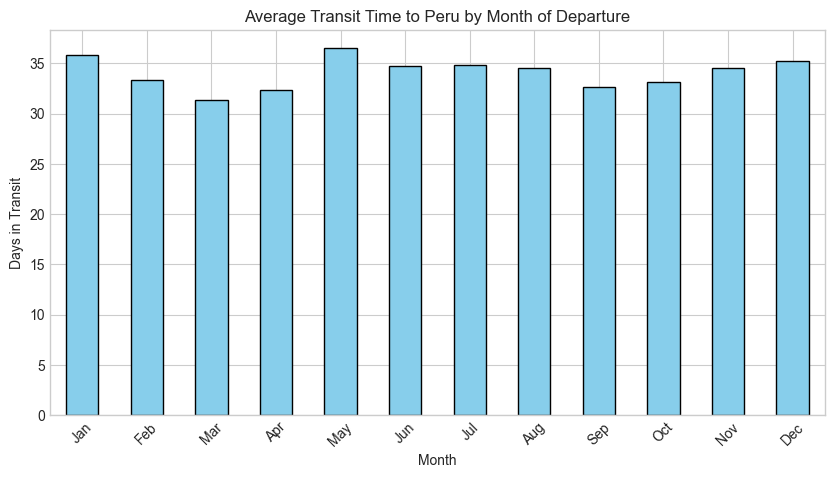

Global Average Transit Time: 34.1 days


In [45]:
# 1. Convert main date columns to datetime
# We use 'coerce' so that unparseable strings become NaT (Null)
df_units['FECHA_EMBARQUE'] = pd.to_datetime(df_units['FECHA DE EMBARQUE'], errors='coerce')
df_units['FECHA_LLEGADA'] = pd.to_datetime(df_units['FECHA DE LLEGADA'], errors='coerce')

# 2. Impute missing arrival dates
# Construct a date string from AÑO, MES, and DIA (defaulting to 1 if DIA is missing)
df_units['DIA_ALT'] = pd.to_numeric(df_units['DIA'], errors='coerce').fillna(1).astype(int)
df_units['FECHA_LLEGADA_ALT'] = pd.to_datetime(
    df_units['ANO'].astype(str) + '-' +
    df_units['MES'].astype(str) + '-' +
    df_units['DIA_ALT'].astype(str),
    errors='coerce'
)

# Fill gaps in arrival date
df_units['FECHA_LLEGADA_FINAL'] = df_units['FECHA_LLEGADA'].fillna(df_units['FECHA_LLEGADA_ALT'])

# 3. Calculate Transit Time (Days)
df_units['TRANSIT_DAYS'] = (df_units['FECHA_LLEGADA_FINAL'] - df_units['FECHA_EMBARQUE']).dt.days

# Filter for realistic transit times (e.g., 5 to 90 days) to remove errors
df_transit = df_units[(df_units['TRANSIT_DAYS'] > 5) & (df_units['TRANSIT_DAYS'] < 100)]

# 4. Seasonal Analysis: Average transit time by Month of Departure
seasonal_transit = df_transit.groupby(df_transit['FECHA_EMBARQUE'].dt.month)['TRANSIT_DAYS'].mean()

plt.figure(figsize=(10, 5))
seasonal_transit.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Average Transit Time to Peru by Month of Departure')
plt.xlabel('Month')
plt.ylabel('Days in Transit')
plt.xticks(range(0, 12), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], rotation=45)
plt.show()

print(f"Global Average Transit Time: {df_transit['TRANSIT_DAYS'].mean():.1f} days")

In [48]:
# 1. Calculate spend by period
early_spend = df_units[df_units['ANO'] <= 2019].groupby('RUC IMPORTADOR')['US$ FOB'].sum()
late_spend = df_units[df_units['ANO'] >= 2020].groupby('RUC IMPORTADOR')['US$ FOB'].sum()

# 2. Compare and find the 'Risers'
success_df = pd.DataFrame({'Early': early_spend, 'Late': late_spend}).fillna(0)
success_df['Growth'] = success_df['Late'] - success_df['Early']

# Criteria: Spent < $100k Early, but > $1M Late
rising_stars = success_df[(success_df['Early'] < 100000) & (success_df['Late'] > 1000000)]
rising_stars['CLIENT_NAME'] = rising_stars.index.map(name_map)

print("--- TOP RISING STARS (Potential High-Growth Clients) ---")
display(rising_stars.sort_values('Late', ascending=False))

--- TOP RISING STARS (Potential High-Growth Clients) ---


,Early,Late,Growth,CLIENT_NAME
RUC IMPORTADOR,,,,
0,0.00,23790265.06,23790265.06,Ley 29733 Protección de datos personales
20487799484,0.00,9072490.44,9072490.44,MATERIALES Y SERVICIOS GENERALES FABRI E.I.R.L.
20606433469,0.00,7017716.87,7017716.87,ECA BUSINESS E.I.R.L.
20103913340,0.00,5127822.86,5127822.86,ORVISA SOCIEDAD ANONIMA
20564211908,0.00,3815117.24,3815117.24,KARMAX S.A.C.
20606365196,0.00,3741387.78,3741387.78,LARF BUSINESS E.I.R.L.
20608277448,0.00,3440880.10,3440880.10,4B GLOBAL EQUIPMENT S.A.C.
20602250866,28430.82,3242362.98,3213932.16,FC MACHINERY & CONSTRUCTION E.I.R.L.
20603602481,38833.00,3174175.52,3135342.52,CRS IMPORTACIONES SOCIEDAD ANONIMA CERRA


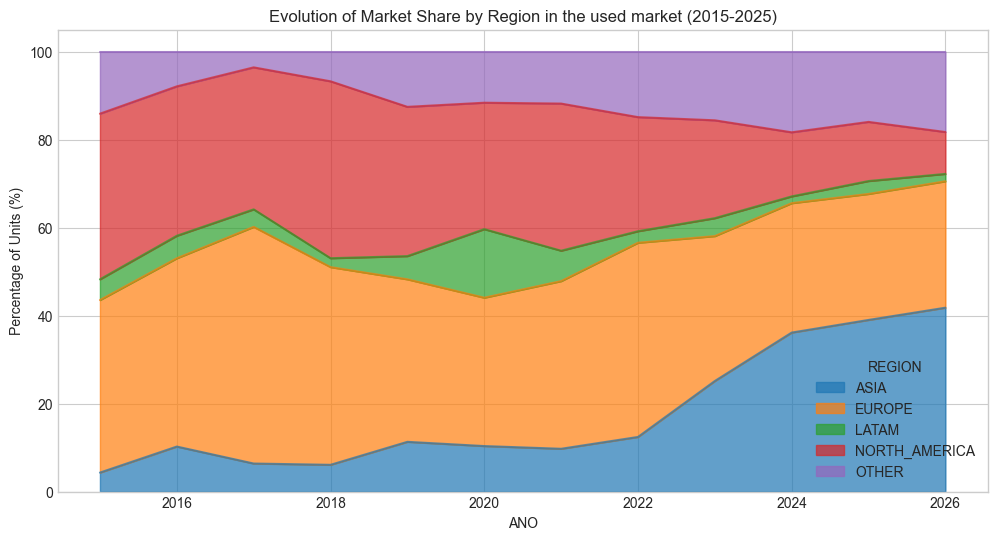

In [50]:
# 1. Define the Macro-Regions
region_map = {
    'SUECIA': 'EUROPE', 'BELGICA': 'EUROPE', 'HOLANDA': 'EUROPE', 'ALEMANIA': 'EUROPE',
    'ITALIA': 'EUROPE', 'REINO UNIDO': 'EUROPE', 'FRANCIA': 'EUROPE', 'ESPAÑA': 'EUROPE',
    'ESTADOS UNIDOS': 'NORTH_AMERICA', 'CANADA': 'NORTH_AMERICA',
    'CHINA': 'ASIA', 'COREA DEL SUR': 'ASIA', 'JAPON': 'ASIA', 'INDIA': 'ASIA',
    'BRASIL': 'LATAM', 'MEXICO': 'LATAM'
}

df_units['REGION'] = df_units['PAIS DE ORIGEN'].map(region_map).fillna('OTHER')

# 2. Regional Market Share Analysis
regional_share = df_units.groupby(['ANO', 'REGION']).size().unstack().fillna(0)
regional_share_pct = regional_share.div(regional_share.sum(axis=1), axis=0) * 100

# Plotting the "Invasion" of Asian brands vs Stability of EU
regional_share_pct.plot(kind='area', stacked=True, figsize=(12, 6), alpha=0.7)
plt.title('Evolution of Market Share by Region in the used market (2015-2025)')
plt.ylabel('Percentage of Units (%)')
plt.show()

In [52]:
# Apply region_map to df_units
df_units['REGION'] = df_units['PAIS DE ORIGEN'].map(region_map).fillna('OTHER')

# Build the RUC x REGION basket (binary: did this importer buy from this region?)
basket_region_sets = (
    df_units.groupby(['RUC IMPORTADOR', 'REGION'])
    .size()
    .unstack(fill_value=0)
    .clip(upper=1)          # binarise: 1 = bought from region, 0 = did not
    .astype(bool)           # mlxtend requires boolean dtype
)

# Regional market presence (share of importers active in each region)
regional_share_pct = basket_region_sets.mean() * 100

print(f"Basket shape: {basket_region_sets.shape}  ({basket_region_sets.shape[0]} importers x {basket_region_sets.shape[1]} regions)")
print("--- % of importers active in each region ---")
print(regional_share_pct.sort_values(ascending=False).round(1))


Basket shape: (1444, 5)  (1444 importers x 5 regions)
--- % of importers active in each region ---
REGION
ASIA             39.3
EUROPE           35.3
NORTH_AMERICA    33.1
OTHER            19.0
LATAM             8.5
dtype: float64


In [54]:
# Check the frequency of each region in your basket
print("--- Regional Market Presence ---")
print(basket_region_sets.mean().sort_values(ascending=False))

--- Regional Market Presence ---
REGION
ASIA             0.392659
EUROPE           0.353186
NORTH_AMERICA    0.331025
OTHER            0.190443
LATAM            0.085180
dtype: float64


In [56]:
from mlxtend.frequent_patterns import apriori, association_rules

# 1. Lower the threshold to find more 'hidden' connections
# min_support = 0.02 means at least 2% of importers must have this combo
freq_regions = apriori(basket_region_sets, min_support=0.02, use_colnames=True)

# 2. Check if we found ANY frequent itemsets with more than 1 region
freq_regions['length'] = freq_regions['itemsets'].apply(lambda x: len(x))
multi_itemsets = freq_regions[freq_regions['length'] > 1]

if multi_itemsets.empty:
    print("❌ Still no combinations found. Importers in your data tend to stick to ONLY one region.")
else:
    # 3. Generate Rules with a lower Lift threshold
    rules_regions = association_rules(freq_regions, metric="lift", min_threshold=0.8)

    print(f"✅ Success! Found {len(rules_regions)} regional associations.")
    display(rules_regions[['antecedents', 'consequents', 'support', 'confidence', 'lift']].sort_values('lift', ascending=False))

✅ Success! Found 48 regional associations.


,antecedents,consequents,support,confidence,lift
42,"frozenset({EUROPE, ASIA})","frozenset({OTHER, NORTH_AMERICA})",0.020083,0.263636,4.642572
39,"frozenset({OTHER, NORTH_AMERICA})","frozenset({EUROPE, ASIA})",0.020083,0.353659,4.642572
41,"frozenset({EUROPE, NORTH_AMERICA})","frozenset({OTHER, ASIA})",0.020083,0.210145,4.397816
40,"frozenset({OTHER, ASIA})","frozenset({EUROPE, NORTH_AMERICA})",0.020083,0.420290,4.397816
43,"frozenset({NORTH_AMERICA, ASIA})","frozenset({OTHER, EUROPE})",0.020083,0.341176,4.283990
38,"frozenset({OTHER, EUROPE})","frozenset({NORTH_AMERICA, ASIA})",0.020083,0.252174,4.283990
37,"frozenset({EUROPE, NORTH_AMERICA, ASIA})",frozenset({OTHER}),0.020083,0.580000,3.045527
44,frozenset({OTHER}),"frozenset({EUROPE, NORTH_AMERICA, ASIA})",0.020083,0.105455,3.045527
36,"frozenset({OTHER, NORTH_AMERICA, ASIA})",frozenset({EUROPE}),0.020083,0.805556,2.280828
45,frozenset({EUROPE}),"frozenset({OTHER, NORTH_AMERICA, ASIA})",0.020083,0.056863,2.280828


In [58]:
from mlxtend.frequent_patterns import apriori, association_rules

# 1. Lower support even more to find the 'Small' crossovers
# 0.01 = 1% of your total RUCs
freq_regions = apriori(basket_region_sets, min_support=0.01, use_colnames=True)

# 2. Focus specifically on the EUROPE-NORTH_AMERICA link
rules_regions = association_rules(freq_regions, metric="lift", min_threshold=0.5)

# 3. Filter for rules that involve EUROPE
europe_rules = rules_regions[
    rules_regions['antecedents'].apply(lambda x: 'EUROPE' in x) |
    rules_regions['consequents'].apply(lambda x: 'EUROPE' in x)
]

print(f"✅ Found {len(europe_rules)} rules involving Europe.")
display(europe_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].sort_values('lift', ascending=False))

✅ Found 58 rules involving Europe.


,antecedents,consequents,support,confidence,lift
80,"frozenset({EUROPE, ASIA})","frozenset({OTHER, NORTH_AMERICA})",0.020083,0.263636,4.642572
77,"frozenset({OTHER, NORTH_AMERICA})","frozenset({EUROPE, ASIA})",0.020083,0.353659,4.642572
79,"frozenset({EUROPE, NORTH_AMERICA})","frozenset({OTHER, ASIA})",0.020083,0.210145,4.397816
78,"frozenset({OTHER, ASIA})","frozenset({EUROPE, NORTH_AMERICA})",0.020083,0.420290,4.397816
81,"frozenset({NORTH_AMERICA, ASIA})","frozenset({OTHER, EUROPE})",0.020083,0.341176,4.283990
76,"frozenset({OTHER, EUROPE})","frozenset({NORTH_AMERICA, ASIA})",0.020083,0.252174,4.283990
82,frozenset({OTHER}),"frozenset({EUROPE, NORTH_AMERICA, ASIA})",0.020083,0.105455,3.045527
75,"frozenset({EUROPE, NORTH_AMERICA, ASIA})",frozenset({OTHER}),0.020083,0.580000,3.045527
83,frozenset({EUROPE}),"frozenset({OTHER, NORTH_AMERICA, ASIA})",0.020083,0.056863,2.280828
74,"frozenset({OTHER, NORTH_AMERICA, ASIA})",frozenset({EUROPE}),0.020083,0.805556,2.280828


In [60]:
#companias que pueden comprarle a cptrucks
# Identify RUCs that have imported from BOTH regions
western_ruc_list = df_units[df_units['REGION'].isin(['EUROPE', 'NORTH_AMERICA'])].groupby('RUC IMPORTADOR')['REGION'].nunique()
western_rucs = western_ruc_list[western_ruc_list == 2].index

# Get their stats
western_tier_prospects = df_units[df_units['RUC IMPORTADOR'].isin(western_rucs)].groupby('RUC IMPORTADOR').agg({
    'US$ FOB': 'sum',
    'PRODUCTO': 'count'
}).rename(columns={'US$ FOB': 'Total_Investment', 'PRODUCTO': 'Unit_Count'}).sort_values('Total_Investment', ascending=False)

# Map names (Use your name_map dictionary)
western_tier_prospects['NAME'] = western_tier_prospects.index.map(name_map)

print("--- THE WESTERN-TIER ELITE ---")
display(western_tier_prospects.head(40))

--- THE WESTERN-TIER ELITE ---


,Total_Investment,Unit_Count,NAME
RUC IMPORTADOR,,,
20538234754,43610122.85,717,MC MACHINERY & ELECTRONIC S.A.C
0,23790265.06,468,Ley 29733 Protección de datos personales
20517931536,9914193.52,189,KARLA EQUIPMENT S.A.C.
20537984032,9606640.38,197,DESERT LOGISTIC SERVICES S.A.C.
20606433469,7017716.87,140,ECA BUSINESS E.I.R.L.
20601770815,6748279.94,110,DAMICON BUSINESS S.A.C.
20100134706,6392561.98,15,SANDVIK DEL PERU S A
20501417646,5501763.09,134,TRANSPORTES GEMAR E.I.R.L.
20518118103,5487038.47,138,TOTAL CAMIONETAS S.A.C.



--- TOP 10 WESTERN-TIER ELITE (Prospects already buying NA + EU Used Gear) ---


,Total_Used_FOB,Used_Units,NAME
RUC IMPORTADOR,,,
20538234754,36448082.83,567,MC MACHINERY & ELECTRONIC S.A.C
0,21585055.33,417,Ley 29733 Protección de datos personales
20517931536,8983324.08,155,KARLA EQUIPMENT S.A.C.
20537984032,8217152.62,155,DESERT LOGISTIC SERVICES S.A.C.
20601770815,6511835.16,102,DAMICON BUSINESS S.A.C.
20606433469,6288320.49,122,ECA BUSINESS E.I.R.L.
20100134706,5881167.06,13,SANDVIK DEL PERU S A
20518118103,5267661.47,131,TOTAL CAMIONETAS S.A.C.
20490425668,5064604.37,77,KALICANTO PERU EIRL.


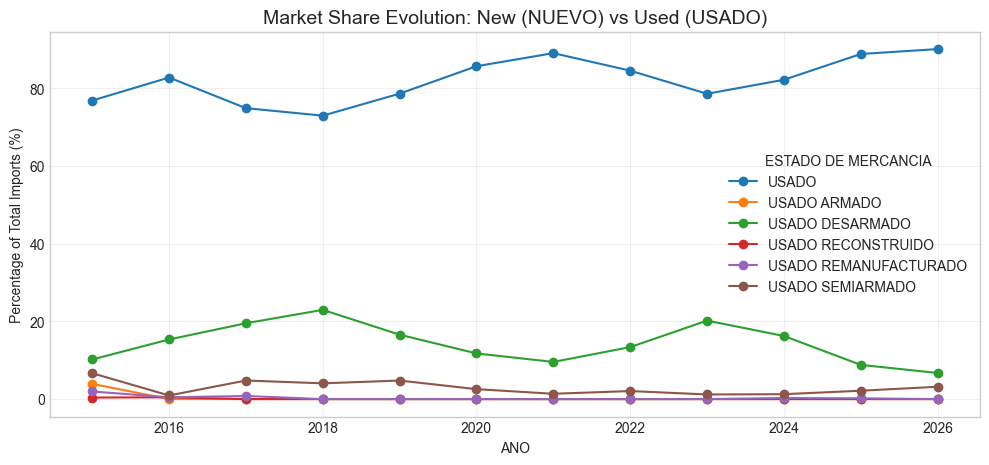

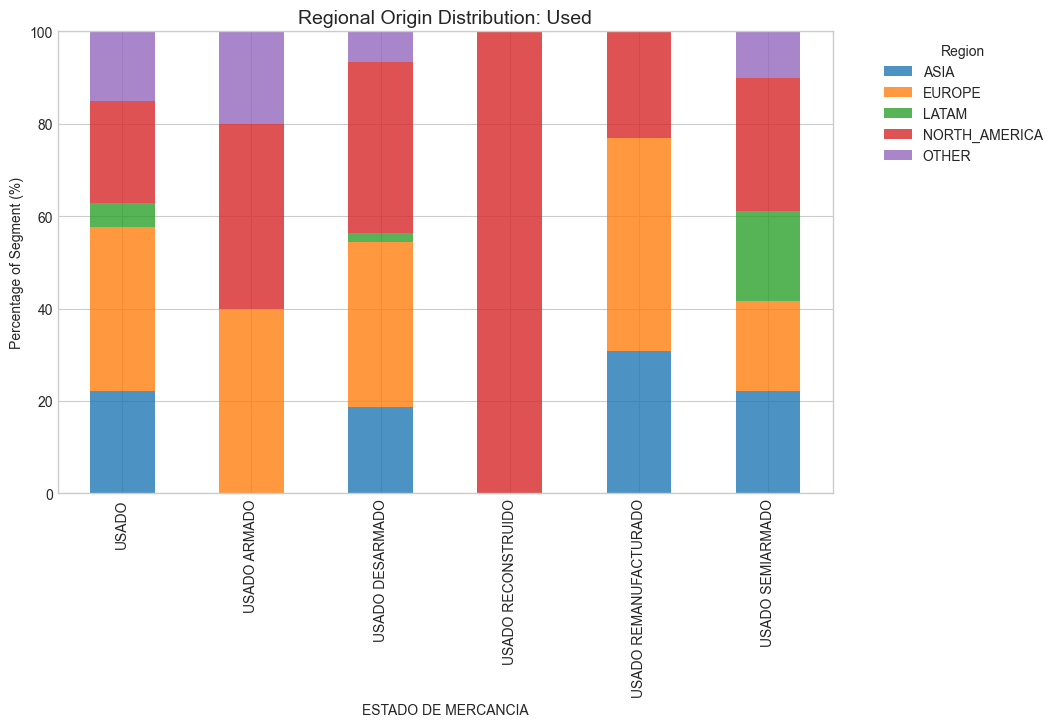


--- Top 10 Brands: NEW Market ---
Series([], Name: count, dtype: int64)

--- Top 10 Brands: USED Market ---
MARCA
CATERPILLAR    2805
VOLVO          2127
HYUNDAI         193
DOOSAN          148
UNKNOWN         122
KOMATSU          91
BOBCAT           61
JOHN DEERE       41
SYMONS           38
Caterpillar      36
Name: count, dtype: int64


In [62]:
df_master = df_units.copy()

# 2. DEFINE MACRO-REGIONS
region_map = {
    'SUECIA': 'EUROPE', 'BELGICA': 'EUROPE', 'HOLANDA': 'EUROPE', 'ALEMANIA': 'EUROPE',
    'ITALIA': 'EUROPE', 'REINO UNIDO': 'EUROPE', 'FRANCIA': 'EUROPE', 'ESPAÑA': 'EUROPE',
    'ESTADOS UNIDOS': 'NORTH_AMERICA', 'CANADA': 'NORTH_AMERICA',
    'CHINA': 'ASIA', 'COREA DEL SUR': 'ASIA', 'JAPON': 'ASIA', 'INDIA': 'ASIA',
    'BRASIL': 'LATAM', 'MEXICO': 'LATAM'
}
df_master['REGION'] = df_master['PAIS DE ORIGEN'].map(region_map).fillna('OTHER')

# 3. IDENTIFY "WESTERN-TIER" ELITE (Targets in the USED Market)
# We filter for 'USADO' then find those buying from both EU and NA
df_used = df_master[df_master['ESTADO DE MERCANCIA'] == 'USADO']
western_ruc_list = df_used[df_used['REGION'].isin(['EUROPE', 'NORTH_AMERICA'])].groupby('RUC IMPORTADOR')['REGION'].nunique()
western_rucs = western_ruc_list[western_ruc_list == 2].index

western_elite = df_used[df_used['RUC IMPORTADOR'].isin(western_rucs)].groupby('RUC IMPORTADOR').agg({
    'US$ FOB': 'sum',
    'PRODUCTO': 'count'
}).rename(columns={'US$ FOB': 'Total_Used_FOB', 'PRODUCTO': 'Used_Units'}).sort_values('Total_Used_FOB', ascending=False)

# Mapping names (using your existing name_map dictionary)
western_elite['NAME'] = western_elite.index.map(name_map)

print("\n--- TOP 10 WESTERN-TIER ELITE (Prospects already buying NA + EU Used Gear) ---")
display(western_elite.head(10))

# 4. TREND ANALYSIS: NEW vs USED
market_trend = df_master.groupby(['ANO', 'ESTADO DE MERCANCIA']).size().unstack().fillna(0)
market_trend_pct = market_trend.div(market_trend.sum(axis=1), axis=0) * 100

plt.figure(figsize=(12, 5))
market_trend_pct.plot(kind='line', marker='o', ax=plt.gca())
plt.title('Market Share Evolution: New (NUEVO) vs Used (USADO)', fontsize=14)
plt.ylabel('Percentage of Total Imports (%)')
plt.grid(True, alpha=0.3)
plt.show()

# 5. REGIONAL ANALYSIS: DO WE TRUST ASIA FOR USED GEAR?
reg_comp = df_master.groupby(['ESTADO DE MERCANCIA', 'REGION']).size().unstack().fillna(0)
reg_comp_pct = reg_comp.div(reg_comp.sum(axis=1), axis=0) * 100

plt.figure(figsize=(10, 6))
reg_comp_pct.plot(kind='bar', stacked=True, ax=plt.gca(), alpha=0.8)
plt.title('Regional Origin Distribution: Used', fontsize=14)
plt.ylabel('Percentage of Segment (%)')
plt.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# 6. BRAND DOMINANCE COMPARISON
print("\n--- Top 10 Brands: NEW Market ---")
print(df_master[df_master['ESTADO DE MERCANCIA'] == 'NUEVO']['MARCA'].value_counts().head(10))

print("\n--- Top 10 Brands: USED Market ---")
print(df_master[df_master['ESTADO DE MERCANCIA'] == 'USADO']['MARCA'].value_counts().head(10))

In [64]:
# Identify RUCs that import from both Europe and North America (Used Market)
df_used = df_master[df_master['ESTADO DE MERCANCIA'] == 'USADO']
regional_counts = df_used[df_used['REGION'].isin(['EUROPE', 'NORTH_AMERICA'])].groupby('RUC IMPORTADOR')['REGION'].nunique()
western_ruc_indices = regional_counts[regional_counts == 2].index

# Aggregate their stats
western_elite = df_used[df_used['RUC IMPORTADOR'].isin(western_ruc_indices)].groupby('RUC IMPORTADOR').agg({
    'US$ FOB': 'sum',
    'PRODUCTO': 'count'
}).rename(columns={'US$ FOB': 'Total_Used_FOB', 'PRODUCTO': 'Used_Units'}).sort_values('Total_Used_FOB', ascending=False)

# Assuming you have your name_map dictionary from the previous steps
western_elite['NAME'] = western_elite.index.map(name_map)

print("--- TOP 20 WESTERN-ELITE PROSPECTS ---")
display(western_elite.head(20))

--- TOP 20 WESTERN-ELITE PROSPECTS ---


,Total_Used_FOB,Used_Units,NAME
RUC IMPORTADOR,,,
20538234754,36448082.83,567,MC MACHINERY & ELECTRONIC S.A.C
0,21585055.33,417,Ley 29733 Protección de datos personales
20517931536,8983324.08,155,KARLA EQUIPMENT S.A.C.
20537984032,8217152.62,155,DESERT LOGISTIC SERVICES S.A.C.
20601770815,6511835.16,102,DAMICON BUSINESS S.A.C.
20606433469,6288320.49,122,ECA BUSINESS E.I.R.L.
20100134706,5881167.06,13,SANDVIK DEL PERU S A
20518118103,5267661.47,131,TOTAL CAMIONETAS S.A.C.
20490425668,5064604.37,77,KALICANTO PERU EIRL.


In [ ]:
# Identify RUCs that import BOTH Europe and NA in the Clean Used market
df_used_clean = df_clean[df_clean['ESTADO DE MERCANCIA'] == 'USADO']
ruc_regional_count = df_used_clean[df_used_clean['REGION'].isin(['EUROPE', 'NORTH_AMERICA'])].groupby('RUC IMPORTADOR')['REGION'].nunique()
target_rucs = ruc_regional_count[ruc_regional_count == 2].index

# Rank them by total investment
prospects = df_used_clean[df_used_clean['RUC IMPORTADOR'].isin(target_rucs)].groupby('RUC IMPORTADOR').agg({
    'US$ FOB': 'sum',
    'PRODUCTO': 'count'
}).rename(columns={'US$ FOB': 'Total_Used_FOB', 'PRODUCTO': 'Unit_Count'}).sort_values('Total_Used_FOB', ascending=False)

# Map names (Assuming you have name_map)
prospects['COMPANY_NAME'] = prospects.index.map(name_map)

print("--- THE PLATINUM PROSPECTS (Target for CPtrucks) ---")
display(prospects.head(20))

In [ ]:
# 1. Filter for Companies only (In Peru, Company RUCs start with '20')
df_companies = df_clean[df_clean['RUC IMPORTADOR'].astype(str).str.startswith('20')].copy()

# 2. Identify the Western-Tier Elite within the Corporate Segment
# (Buying from both North America and Europe)
df_used_corp = df_companies[df_companies['ESTADO DE MERCANCIA'] == 'USADO']
corp_regional_count = df_used_corp[df_used_corp['REGION'].isin(['EUROPE', 'NORTH_AMERICA'])].groupby('RUC IMPORTADOR')['REGION'].nunique()
target_corp_rucs = corp_regional_count[corp_regional_count == 2].index

# 3. Create the Final Corporate Hit List
corporate_leads = df_used_corp[df_used_corp['RUC IMPORTADOR'].isin(target_corp_rucs)].groupby('RUC IMPORTADOR').agg({
    'US$ FOB': 'sum',
    'PRODUCTO': 'count'
}).rename(columns={'US$ FOB': 'Total_Used_FOB', 'PRODUCTO': 'Unit_Count'}).sort_values('Total_Used_FOB', ascending=False)

# Map names (ignore 'Ley de proteccion' here)
corporate_leads['COMPANY_NAME'] = corporate_leads.index.map(name_map)

print("--- TOP 20 CORPORATE TARGETS (RUC 20 only) ---")
display(corporate_leads.head(20))

In [70]:
# 1. Clean and Filter
df_clean = df_master[
    (df_master['ESTADO DE MERCANCIA'] == 'USADO') &
    (df_master['RUC IMPORTADOR'].astype(str).str.startswith('20'))
].copy()

# 2. Aggregate
ruc_region_stats = df_clean.groupby(['RUC IMPORTADOR', 'REGION']).agg({
    'US$ FOB': 'sum',
    'PRODUCTO': 'count'
}).unstack(fill_value=0)

# 3. Flatten columns safely
ruc_region_stats.columns = [f"{col[1]}_{col[0]}" for col in ruc_region_stats.columns]

# --- ROBUSTNESS FIX ---
# We ensure the columns we need exist, even if they are all zeros
required_cols = ['EUROPE_count', 'NORTH_AMERICA_count', 'EUROPE_US$ FOB', 'NORTH_AMERICA_US$ FOB']
for col in required_cols:
    if col not in ruc_region_stats.columns:
        ruc_region_stats[col] = 0

# 4. Apply the 'Blue Ocean' Filter:
# ZERO Europe AND at least one North America
blue_ocean_filter = (ruc_region_stats['EUROPE_count'] < 10000000) & (ruc_region_stats['NORTH_AMERICA_count'] > 0)
blue_oceans = ruc_region_stats[blue_ocean_filter].copy()

# 5. Get Company Names and Top Brands
# We merge back with master to get descriptive info
names = df_clean.groupby('RUC IMPORTADOR')['IMPORTADOR'].first()
brands = df_clean.groupby('RUC IMPORTADOR')['MARCA'].agg(lambda x: x.mode()[0] if not x.mode().empty else "Various")

blue_oceans['COMPANY_NAME'] = blue_oceans.index.map(names)
blue_oceans['TOP_BRAND'] = blue_oceans.index.map(brands)

# 6. Final Sort and Display
blue_oceans = blue_oceans.sort_values('NORTH_AMERICA_US$ FOB', ascending=False)

print(f"Identified {len(blue_oceans)} Corporate Blue Oceans.")
display(blue_oceans[['COMPANY_NAME', 'NORTH_AMERICA_US$ FOB', 'NORTH_AMERICA_count', 'TOP_BRAND']].head(20))

# Export for your thesis appendix
blue_oceans.to_csv('BLUE_OCEAN_PROSPECTS_USA_LOYALISTS.csv')

Identified 0 Corporate Blue Oceans.


,COMPANY_NAME,NORTH_AMERICA_US$ FOB,NORTH_AMERICA_count,TOP_BRAND
RUC IMPORTADOR,,,,


In [ ]:
#EXTRa
# 1. Surgical Noise Filter
# We exclude protected data, individuals, and financial institutions
noise_mask = 'PROTECCION|PERSONALES|BANCO|BANK|LEASING|CREDITO|FINANCI|CONTINENTAL|SCOTIA'
df_corp_clean = df_clean[
    (df_clean['RUC IMPORTADOR'].astype(str).str.startswith('20')) &
    (~df_clean['IMPORTADOR'].str.contains(noise_mask, case=False, na=False))
].copy()

# 2. Re-run Grey Ocean Logic
whale_stats = df_corp_clean.groupby(['RUC IMPORTADOR', 'REGION'])['US$ FOB'].sum().unstack(fill_value=0)
whale_stats['Total_FOB'] = whale_stats.sum(axis=1)

# Ensure columns exist
for c in ['NORTH_AMERICA', 'EUROPE']:
    if c not in whale_stats.columns: whale_stats[c] = 0

whale_stats['NA_Bias'] = (whale_stats['NORTH_AMERICA'] / whale_stats['Total_FOB']) * 100
whale_stats['EU_Share'] = (whale_stats['EUROPE'] / whale_stats['Total_FOB']) * 100

# 3. The "Actionable Dolphin" Filter
# - Spend > $300,000 (The "Sweet Spot" for B2B Sales)
# - NA Bias > 70%
# - EU Share < 10%
dolphins = whale_stats[
    (whale_stats['Total_FOB'] > 300000) &
    (whale_stats['NA_Bias'] > 70) &
    (whale_stats['EU_Share'] < 10)
].copy()

# 4. Map Names and Top Brands
dolphins['COMPANY_NAME'] = dolphins.index.map(name_map)
brands = df_corp_clean.groupby('RUC IMPORTADOR')['MARCA'].agg(lambda x: x.mode()[0] if not x.mode().empty else "Mix")
dolphins['PRIMARY_BRAND'] = dolphins.index.map(brands)

print(f"✅ Found {len(dolphins)} Identifiable Corporate 'Dolphins' (Actionable Leads).")
display(dolphins[['COMPANY_NAME', 'Total_FOB', 'NA_Bias', 'PRIMARY_BRAND']].sort_values('Total_FOB', ascending=False).head(30))

### CPTrucks Share-of-Wallet Analysis

In [76]:
# 1. Flag transactions from your company (CPtrucks)
# Note: Check if the exporter name in your CSV is 'CP TRUCK', 'CPTRUCKS', etc.
df_used_market['is_cptrucks'] = df_used_market['PROBABLE EMBARCADOR'].str.contains('CP TRUCK', na=False, case=False)

# 2. Calculate total spend vs spend with you
sow_df = df_used_market.groupby('RUC IMPORTADOR').agg(
    Total_Imported_FOB=('US$ FOB', 'sum'),
    CPtrucks_FOB=('US$ FOB', lambda x: x[df_used_market.loc[x.index, 'is_cptrucks']].sum())
)

# 3. Final SoW percentage
sow_df['Share_of_Wallet'] = (sow_df['CPtrucks_FOB'] / sow_df['Total_Imported_FOB']) * 100

In [78]:
### SOW

# 1. Define your internal sales data (from your Belgian invoices)
# Mapping RUC to the Sales Sum from your screenshot
internal_sales_data = {
    '20517931536': 1636379, # KARLA EQUIPMENT
    '20490425668': 1157475, # KALICANTO
    '20602250866': 1149356, # FC MACHINERY
    '20519006422': 483564,  # TACKLLA
    '20606954442': 390337,  # ECA PERU
    '20601770815': 338473,  # DAMICON
    '10075145778': 36105,   # Perez Cahuana
    '20601066255': 36014,   # Transp. Const. D&Y
    '20606365196': 24027,   # LARF BUSINESS
    '20456340785': 24001,   # B&J CONTRATISTAS
    '20603430167': 22023,   # JYC INTERNATIONAL
    '20537454076': 17033,   # INVERSIONES RUMALDO
    '20609926440': 11800        # ANKARA PERU
}

# 2. Extract Total Market Activity for these specific clients
# We use the clean used-machinery dataset (df_units)
client_ruc_list = list(internal_sales_data.keys())

market_activity = df_units[df_units['RUC IMPORTADOR'].isin(client_ruc_list)].groupby('RUC IMPORTADOR').agg(
    Total_Imported_FOB=('US$ FOB', 'sum'),
    Transactions=('RUC IMPORTADOR', 'count'),
    Avg_Price_Per_Unit=('US$ FOB', 'mean'),
    Main_Origin=('PAIS DE ORIGEN', lambda x: x.mode()[0] if not x.mode().empty else "Unknown")
)

# 3. Combine Internal vs External
sow_results = market_activity.copy()
sow_results['Sales_From_CPTRUCKS'] = sow_results.index.map(internal_sales_data)

# Calculate the Share of Wallet (%)
sow_results['Share_of_Wallet'] = (sow_results['Sales_From_CPTRUCKS'] / sow_results['Total_Imported_FOB']) * 100

# Add Client Names for readability
sow_results['CLIENT_NAME'] = sow_results.index.map(name_map) # Using the name_map we created earlier

# 4. Final Table
sow_final = sow_results[['CLIENT_NAME', 'Sales_From_CPTRUCKS', 'Total_Imported_FOB', 'Share_of_Wallet', 'Transactions', 'Main_Origin']]
sow_final = sow_final.sort_values('Total_Imported_FOB', ascending=False)

pd.options.display.float_format = '{:,.2f}'.format
display(sow_final)

,CLIENT_NAME,Sales_From_CPTRUCKS,Total_Imported_FOB,Share_of_Wallet,Transactions,Main_Origin
RUC IMPORTADOR,,,,,,
20517931536,KARLA EQUIPMENT S.A.C.,1636379,"9,914,193.52",16.51,189,BELGICA
20601770815,DAMICON BUSINESS S.A.C.,338473,"6,748,279.94",5.02,110,SUECIA
20490425668,KALICANTO PERU EIRL.,1157475,"5,378,581.24",21.52,89,ESTADOS UNIDOS
20606365196,LARF BUSINESS E.I.R.L.,24027,"3,741,387.78",0.64,54,ESTADOS UNIDOS
20602250866,FC MACHINERY & CONSTRUCTION E.I.R.L.,1149356,"3,270,793.80",35.14,67,FRANCIA
20603430167,JYC INTERNATIONAL BUSINESS S.A.C.,22023,"1,930,629.52",1.14,28,SUECIA
20519006422,TACKLLA PERU SAC,483564,"1,820,325.02",26.56,34,FRANCIA
20609926440,ANKARA PERU E.I.R.L,11800,"810,295.91",1.46,11,JAPON
20456340785,INVERSIONES Y NEGOCIOS B & J CONTRATISTAS GENE...,24001,"86,600.00",27.71,1,JAPON


### Module 2 — Differential Market Basket Analysis per Cluster
FP-Growth association rules mined globally on the **core importer population**
(whales excluded by Isolation Forest in Module 1), then annotated per
**Stage 2 GMM cluster**. A Cluster Index (CI = cluster support / global support)
identifies which rules over-index in each segment. CI >= 1.5 flags cluster-exclusive signals.

  MODULE 2 -- Differential MBA (Core Population, Stage 2 GMM)

  Building BRAND_TYPE basket (core importers, whales excluded) ...
  Source: df_iron
  Basket: 1,204 importers x 40 BRAND_TYPEs

  Global FP-Growth (min_support=0.02) ...
  Frequent itemsets found: 15
  Global rules found: 1

  Top 15 global rules by lift:


/Users/fabriziocontreras/Desktop/KUL/Masters/Thesis/venv/lib/python3.12/site-packages/mlxtend/frequent_patterns/fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


,IF,THEN,support,confidence,lift
0,VOLVO_EXCAVADORA,VOLVO_CARGADOR FRONTAL,0.030,0.340,1.323



  STAGE 2 CLUSTER DIFFERENTIAL ANALYSIS
  CI = cluster_support / global_support | CI >= 1.5 = over-indexed

  Clusters to annotate (n >= 5 in basket): [0, 1, 3, 4, 5, 6]

  Stage 2 Cluster 0  (n=125 importers in basket)


,IF,THEN,Global_Support,Global_Lift,Cluster_Support,Cluster_Index
0,VOLVO_EXCAVADORA,VOLVO_CARGADOR FRONTAL,0.030,1.323,0.184,6.154


...


  Stage 2 Cluster 5  (n=7 importers in basket)


,IF,THEN,Global_Support,Global_Lift,Cluster_Support,Cluster_Index
0,VOLVO_EXCAVADORA,VOLVO_CARGADOR FRONTAL,0.030,1.323,0.000,0.000



  Stage 2 Cluster 6  (n=120 importers in basket)


,IF,THEN,Global_Support,Global_Lift,Cluster_Support,Cluster_Index
0,VOLVO_EXCAVADORA,VOLVO_CARGADOR FRONTAL,0.030,1.323,0.058,1.951



  CROSS-CLUSTER CI HEATMAP


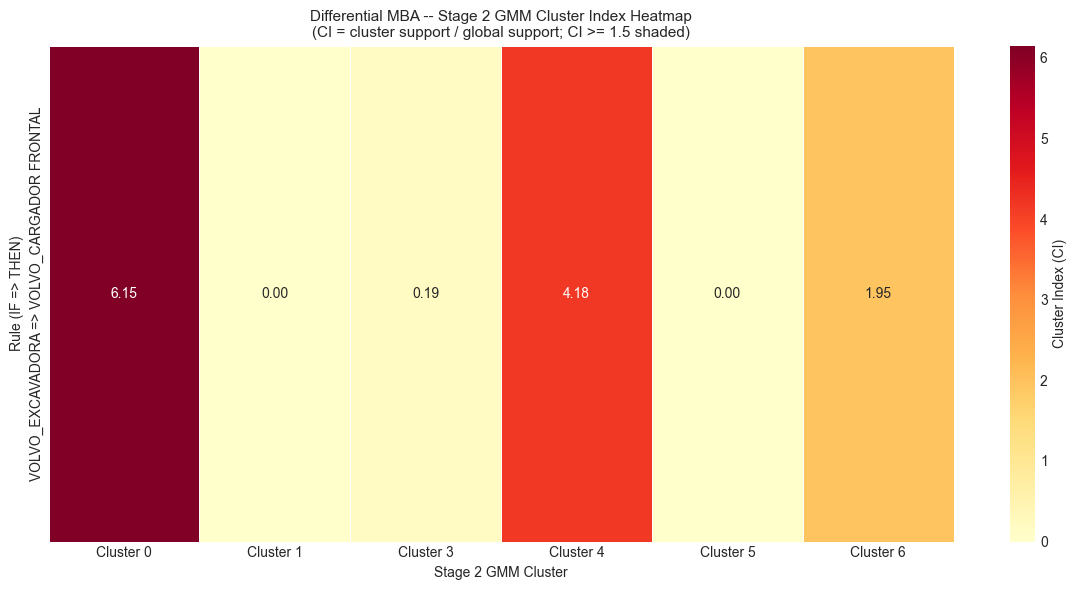


  Cluster-exclusive signals (highest CI not shared with other clusters):
    Cluster 0 -- all over-indexed rules also appear in other clusters
    Cluster 1 -- no over-indexed rules
    Cluster 3 -- no over-indexed rules
    Cluster 4 -- all over-indexed rules also appear in other clusters
    Cluster 5 -- no over-indexed rules
    Cluster 6 -- all over-indexed rules also appear in other clusters

  Module 2 complete.


In [81]:
# MODULE 2 -- Differential Market Basket Analysis (Global + Cluster Annotation)
# =========================================================================
# Approach:
#   1. Build a BRAND_TYPE basket from the CORE importer population (whales excluded).
#   2. Run global FP-Growth to find universally frequent brand-product co-purchases.
#   3. For each Stage 2 GMM cluster, compute:
#        Cluster Index (CI) = cluster_support / global_support
#      CI > 1 = over-represented; CI >= 1.5 = cluster-exclusive signal.
#   4. Produce a cross-cluster heatmap for the thesis narrative.
# =========================================================================

from mlxtend.frequent_patterns import fpgrowth, association_rules
import matplotlib.pyplot as plt
import seaborn as sns

MIN_SUPPORT_GLOBAL = 0.02   # 2% of ~1371 core importers ~ 27 importers
MIN_CONFIDENCE     = 0.25
MIN_LIFT           = 1.2
TOP_N_BRANDS       = 40
CI_THRESHOLD       = 1.5

print('=' * 64)
print('  MODULE 2 -- Differential MBA (Core Population, Stage 2 GMM)')
print('=' * 64)

# Step 0: Build basket from core importers only
print('\n  Building BRAND_TYPE basket (core importers, whales excluded) ...')
_core_rucs = set(df_core.index.astype(str))

try:
    _src = df_iron.copy()
    print('  Source: df_iron')
except NameError:
    _src = df_units.copy()
    _src['BRAND_TYPE'] = (
        _src.get('MARCA_CLEAN', _src.get('MARCA', 'UNKNOWN')).fillna('UNKNOWN') + '_' +
        _src.get('PRODUCTO_CLEAN', _src.get('PRODUCTO', 'UNKNOWN')).fillna('UNKNOWN')
    )
    print('  Source: df_units (df_iron not in scope)')

_src = _src[
    _src['RUC IMPORTADOR'].astype(str).isin(_core_rucs) &
    _src['BRAND_TYPE'].notna() &
    (~_src['BRAND_TYPE'].str.contains('UNKNOWN', na=False))
].copy()
_src['RUC IMPORTADOR'] = _src['RUC IMPORTADOR'].astype(str)

_top_bt  = _src['BRAND_TYPE'].value_counts().nlargest(TOP_N_BRANDS).index
_src     = _src[_src['BRAND_TYPE'].isin(_top_bt)]

_basket_full = (
    _src.groupby(['RUC IMPORTADOR', 'BRAND_TYPE'])['US$ FOB']
    .count().unstack(fill_value=0)
    .map(lambda x: 1 if x >= 1 else 0)
)

# Attach Stage 2 cluster label
_stage2_map_str = {str(k): v for k, v in stage2_map.items()}
_basket_full['Stage2_Cluster'] = _basket_full.index.map(_stage2_map_str)

print(f'  Basket: {len(_basket_full):,} importers x {len(_basket_full.columns)-1} BRAND_TYPEs')

# Step 1: Global FP-Growth
print(f'\n  Global FP-Growth (min_support={MIN_SUPPORT_GLOBAL}) ...')
_basket_items = _basket_full.drop(columns=['Stage2_Cluster'])
_basket_items = _basket_items.loc[:, _basket_items.sum() > 0]

_freq_global = fpgrowth(_basket_items, min_support=MIN_SUPPORT_GLOBAL, use_colnames=True)
print(f'  Frequent itemsets found: {len(_freq_global)}')

if _freq_global.empty:
    print(f'  No itemsets at min_support={MIN_SUPPORT_GLOBAL}. '
          f'Basket: {_basket_items.shape}, avg items/importer: '
          f'{_basket_items.sum(axis=1).mean():.2f}. Try lowering MIN_SUPPORT_GLOBAL.')
    _rules_global = pd.DataFrame(columns=['antecedents','consequents','support',
                                           'confidence','lift','ant_str','con_str'])
else:
    _rules_global = association_rules(_freq_global, metric='lift', min_threshold=MIN_LIFT)
    _rules_global = _rules_global[_rules_global['confidence'] >= MIN_CONFIDENCE].copy()
    _rules_global['ant_str'] = _rules_global['antecedents'].apply(lambda x: ', '.join(sorted(x)))
    _rules_global['con_str'] = _rules_global['consequents'].apply(lambda x: ', '.join(sorted(x)))

print(f'  Global rules found: {len(_rules_global)}')
print('\n  Top 15 global rules by lift:')
display(
    _rules_global.sort_values('lift', ascending=False)
    .head(15)[['ant_str', 'con_str', 'support', 'confidence', 'lift']]
    .rename(columns={'ant_str': 'IF', 'con_str': 'THEN'})
    .reset_index(drop=True)
    .style.format({'support': '{:.3f}', 'confidence': '{:.3f}', 'lift': '{:.3f}'})
    .background_gradient(subset=['lift'], cmap='YlOrRd')
)

# Step 2: Cluster-level differential analysis
print('\n' + '=' * 64)
print('  STAGE 2 CLUSTER DIFFERENTIAL ANALYSIS')
print('=' * 64)
print(f'  CI = cluster_support / global_support | CI >= {CI_THRESHOLD} = over-indexed\n')

# Only annotate clusters with >= 5 importers in the basket
_cl_counts = _basket_full['Stage2_Cluster'].value_counts().dropna()
_annotate_clusters = sorted(_cl_counts[_cl_counts >= 5].index.astype(int).tolist())
print(f'  Clusters to annotate (n >= 5 in basket): {_annotate_clusters}')

_diff_records = []
for _cl in _annotate_clusters:
    _cl_rucs   = _basket_full[_basket_full['Stage2_Cluster'] == _cl].index
    _basket_cl = _basket_items.loc[_basket_items.index.isin(_cl_rucs)]
    _n_cl      = len(_basket_cl)

    for _, _rule in _rules_global.iterrows():
        _ant     = list(_rule['antecedents'])
        _con     = list(_rule['consequents'])
        _has_ant = (_basket_cl[_ant] == 1).all(axis=1)
        _has_con = (_basket_cl[_con] == 1).all(axis=1)
        _cl_supp = (_has_ant & _has_con).sum() / max(_n_cl, 1)
        _ci      = _cl_supp / max(_rule['support'], 1e-9)
        _diff_records.append({
            'Cluster':         _cl,
            'IF':              _rule['ant_str'],
            'THEN':            _rule['con_str'],
            'Global_Support':  round(_rule['support'], 3),
            'Global_Lift':     round(_rule['lift'], 3),
            'Cluster_Support': round(_cl_supp, 3),
            'Cluster_Index':   round(_ci, 3),
        })

_diff_df = pd.DataFrame(_diff_records) if _diff_records else \
           pd.DataFrame(columns=['Cluster','IF','THEN','Global_Support',
                                 'Global_Lift','Cluster_Support','Cluster_Index'])

# Per-cluster top rules by CI
for _cl in _annotate_clusters:
    if _diff_df.empty or 'Cluster' not in _diff_df.columns:
        print(f'  Cluster {_cl}: no records (global rules empty).')
        continue
    _sub = _diff_df[_diff_df['Cluster'] == _cl].copy()
    if _sub.empty:
        continue
    _n   = int(_cl_counts.get(_cl, 0))
    _top = _sub.sort_values('Cluster_Index', ascending=False).head(10)
    print(f'\n  Stage 2 Cluster {_cl}  (n={_n} importers in basket)')
    display(
        _top[['IF', 'THEN', 'Global_Support', 'Global_Lift',
              'Cluster_Support', 'Cluster_Index']]
        .reset_index(drop=True)
        .style
        .format({c: '{:.3f}' for c in ['Global_Support', 'Global_Lift',
                                        'Cluster_Support', 'Cluster_Index']})
        .apply(lambda col: [
            'background-color: #d4edda' if v >= CI_THRESHOLD else ''
            for v in col
        ], subset=['Cluster_Index'])
    )

# Cross-cluster heatmap
print('\n' + '=' * 64)
print('  CROSS-CLUSTER CI HEATMAP')
print('=' * 64)

if not _diff_df.empty:
    _diff_df['Rule'] = _diff_df['IF'] + ' => ' + _diff_df['THEN']
    _pivot = (
        _diff_df.pivot_table(index='Rule', columns='Cluster',
                             values='Cluster_Index', aggfunc='mean')
        .fillna(0)
    )
    _pivot = _pivot[(_pivot >= CI_THRESHOLD).any(axis=1)]
    _pivot.columns = [f'Cluster {c}' for c in _pivot.columns]

    if not _pivot.empty:
        fig, ax = plt.subplots(figsize=(max(10, len(_pivot.columns) * 2),
                                        max(6, len(_pivot) * 0.45)))
        sns.heatmap(_pivot, annot=True, fmt='.2f', cmap='YlOrRd',
                    linewidths=0.4, ax=ax,
                    cbar_kws={'label': 'Cluster Index (CI)'})
        ax.set_title(
            f'Differential MBA -- Stage 2 GMM Cluster Index Heatmap\n'
            f'(CI = cluster support / global support; CI >= {CI_THRESHOLD} shaded)',
            fontsize=11)
        ax.set_xlabel('Stage 2 GMM Cluster'); ax.set_ylabel('Rule (IF => THEN)')
        plt.tight_layout(); plt.show()
    else:
        print(f'  No rules with CI >= {CI_THRESHOLD} in any cluster.')

# Cluster-exclusive rule summary
print('\n  Cluster-exclusive signals (highest CI not shared with other clusters):')
for _cl in _annotate_clusters:
    _sub = _diff_df[
        (_diff_df['Cluster'] == _cl) &
        (_diff_df['Cluster_Index'] >= CI_THRESHOLD)
    ]
    if _sub.empty:
        print(f'    Cluster {_cl} -- no over-indexed rules')
        continue
    for _, _row in _sub.sort_values('Cluster_Index', ascending=False).iterrows():
        _others = _diff_df[
            (_diff_df['Cluster'] != _cl) &
            (_diff_df['IF'] == _row['IF']) &
            (_diff_df['THEN'] == _row['THEN']) &
            (_diff_df['Cluster_Index'] >= CI_THRESHOLD)
        ]
        if _others.empty:
            print(f'    Cluster {_cl}: IF [{_row["IF"]}] => THEN [{_row["THEN"]}]'
                  f'  CI={_row["Cluster_Index"]:.3f}  lift={_row["Global_Lift"]:.3f}')
            break
    else:
        print(f'    Cluster {_cl} -- all over-indexed rules also appear in other clusters')

print('\n  Module 2 complete.')


In [83]:
# Save MBA outputs for timeseries_phase_five.ipynb
import pickle, os

_handoff = {
    # Pass-throughs from clustering
    'df_units':          df_units,
    'df_used_market':    df_used_market,
    'name_map':          name_map,
    'segmentation_data': segmentation_data,
    'df_core':           df_core,
    'df_whale':          df_whale,
    'lrfm':              lrfm,
    'best_k_core':       best_k_core,
    # Built in MBA
    'success_stories':   success_stories,
    'sow_final':         sow_final,
}
_handoff_path = 'mba_handoff.pkl'
with open(_handoff_path, 'wb') as _f:
    pickle.dump(_handoff, _f)
print(f'Saved MBA handoff -> {os.path.abspath(_handoff_path)}')
print(f'  df_units shape       : {df_units.shape}')
print(f'  df_core shape        : {df_core.shape}')
print(f'  df_whale shape       : {df_whale.shape}')
print(f'  Stage 2 k            : {best_k_core}')
print(f'  lrfm included        : {lrfm is not None}')
print(f'  success_stories rows : {len(success_stories)}')
print(f'  sow_final rows       : {len(sow_final)}')


Saved MBA handoff -> /Users/fabriziocontreras/Desktop/KUL/Masters/Thesis/code/mba_handoff.pkl
  df_units shape       : (7539, 46)
  df_core shape        : (1371, 11)
  df_whale shape       : (73, 9)
  Stage 2 k            : 7
  lrfm included        : True
  success_stories rows : 76
  sow_final rows       : 10
